# Optimizer comparision

In this project, we will compare some popular optimizers, and explain the math and formulas behind these techniques, before test them in some interesting functions

## What optimizers are?

The optimizers, are iterative methods used to try to minimize a cost function, reaching a minimum. These methods are based on mathematical concepts, such as the gradient. They are used in machine learning, because they provide benefits when optimizing a function and finding the best parameters for our model.

Here we will discuss about the main ones, as well as explain and test them in complex functions. We will cover Momentum, Adam, AdaGrad, RSMProp, Newton, SGD, and Conjugated Gradient. As we will see, they are extremely useful with convex functions, but they also can work for non convex functions 

## Functions to optimize

To test the optimizers and compare them in a real complex situation, we will be using some popular functions in the machine learning and optimization area. These are known because could complicate the algorithm when trying to reach a global minimum.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def himmelblau(w):
    return (w[0]**2 + w[1] - 11) ** 2 + (w[0] + w[1] ** 2 - 7)**2

def rosenbrock(w, a=1., b=100.):
    return (a - w[0]) ** 2 + b * (w[1] - w[0] ** 2) ** 2

def beale(w):
    return (3/2 - w[0] + w[0] * w[1]) ** 2 + (9/4 - w[0] + w[0] * w[1] ** 2) ** 2 + (21/8 - w[0] + w[0] * w[1] ** 3) ** 2

Once we defined them, lets plot to see how they look like

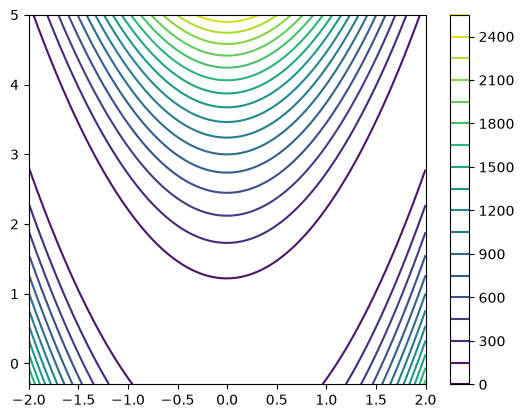

In [ ]:
xlist = np.linspace(-2.0, 2.0, 100)
ylist = np.linspace(-0.3, 5.0, 100)
X, Y = np.meshgrid(xlist, ylist)

Z = np.zeros([100, 100])
for i in range(0, 100):
    for j in range(0, 100):
        w = [X[i, j], Y[i, j]]
        Z[i, j] = rosenbrock(w)

fig, ax = plt.subplots(1, 1)

cp = ax.contour(X, Y, Z, levels = 20)
fig.colorbar(cp)

plt.show()

## Optimizers

### SGD

The Stochastic Gradient Descent is a optimization method that seek for the best path each iteration. The best path will be defined by the gradient of the cost function. So we want to move in the direction that more decreases the cost function value, based on just one instance, randomly chosen. But we will do it, in a way that each epoch (with n iterations, n = num of instances) will update the step using one and just one time each instance. This way, our opimizer will move a little randomly, and making some random jumps, but in general moving towards a minimum (global or local)

In [4]:
def SGD(X, y, f, grad, batch_size=16, alpha=0.1, max_iter=100, tol=1e-3):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    steps = [w.copy()]
    losses = []

    for epoch in range(max_iter):
        loss_epochs = []

        idx = np.random.permutation(n_samples)
        X_shuffled = X[idx]
        y_shuffled = y[idx]

        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]

            grad_w = grad(w, X_batch, y_batch)
            w = w - alpha * grad_w

            total_loss = f(w, X_batch, y_batch)
            loss_epochs.append(total_loss)

            if np.linalg.norm(grad_w) < tol: 
                break
                
        
        losses.append(np.mean(loss_epochs))
        steps.append(w.copy())

        return np.asarray(steps), w, losses

### Momentum

Momentum is used with AGD (Accelerated Gradient Descent). Its a extension of the GD.

Momentum could be understood as the *intertia* of the steps when minimizing a function, going towards the minima. It introduce a *memory*, that accumulates the previous movement, and combine it with the actual step

How do we compute it? Using GD, but instead of just subtract the $\alpha * \nabla f$, we also subtract a new term: $\beta v_{t-1}$. Beta tell the model how much the inertia counts, and $v_{t-1}$ add a small force into de previous best direction

So the update of AGD will be: $$w_{t+1} = w_t - v_t$$, with $$v_t = \beta v_{t-1} + \alpha \nabla J(w_{t-1})$$

Another interpretation is:

Let be $$y_t = w_t + \beta (w_t - w_{t-1})$$, then the update will be $$w_{t+1} = y_t + \alpha \nabla f(w_{t-1})$$

In [5]:
def AGD(w0, grad, alpha=0.001, beta=0.9, max_iter=1000, tol=0.01):
    w = w0
    steps = [w.copy()]
    
    for i in range(max_iter):
        if i > 0:
            w_old = steps[i-1]
            delta_w = w - w_old
        else:
            delta_w = w

        # Momentum update
        y_w = w + beta * delta_w

        # Update step
        w = y_w - alpha * grad(w)

        # Save hist
        steps.append(w)

        diff = grad(w)
        norm = np.linalg.norm(diff)

        if norm < tol:
            break

    return steps, w

### Nesterov Momentum
This optimizers is very similar to the Momentum. But with a slight difference. We will update the gradient with forecasting, using the 'future'. This way we improve the stability, specially in convex problems.

This new update will be:

$$w_{t+1} = y_t + \alpha \nabla f(y_t)$$

with $$y_t = w_t + \beta (w_t - w_{t-1})$$ the momentum 

In [6]:
def NAD(w0, grad, alpha=0.001, beta=0.9, max_iter=1000, tol=0.01):
    w = w0
    steps = [w.copy()]
    
    for i in range(max_iter):
        if i > 0:
            w_old = steps[i-1]
            delta_w = w - w_old
        else:
            delta_w = w

        # Momentum update
        y_w = w + beta * delta_w

        # Update step
        w = y_w - alpha * grad(y_w)

        # Save hist
        steps.append(w)

        diff = grad(w)
        norm = np.linalg.norm(diff)

        if norm < tol:
            break

    return steps, w

## Adaptative optimizers

This type of optimizer preconditions the GD, with the following formula

$$w_{t+1} = w_t - \alpha_t M^{-1}_t \nabla f(w_t)$$

with $M_t$ the preconditioning matrix (usually $M_t > 0$)

### AdaGrad

It accumulates $[\nabla J (w_i)]^2$ and uses it to adjust $\alpha$ on each parameter

The update looks like this: $$w_{t+1,i} = w_{t,i} - \alpha_t \frac{1}{\epsilon + \sqrt{\sum^t_{r=1}\nabla (J(w_{t,i}))^2}} \nabla J(w_{t,i})$$

where $i=1, \dots, D$ and $\epsilon > 0$

The vectorial way is $$w_{t+1} = w_t - \alpha_t \frac{1}{\sqrt{S_t} + \epsilon} \nabla J(w_t)$$

con $S_t = \sum^t_{r=1} [\nabla J(w_r)]^2$

This causes the following effects:
- Big $\nabla$ reduce step
- Small $\nabla$ increase step

With $\nabla$ accumulated it increases indefinitely, so the effect loss strength and the learning rate tends to 0

In [7]:
def AdaGrad(w0, grad, alpha=1, eps=1e-8, max_iter=100, tol=0.0001):
    ws = [w0.copy()] # w steps
    w = w0.copy()
    grads = []
    alphas = []
    Gt = np.zeros_like(w)

    for i in range(0, max_iter):
        # sum pasts gradients
        g = grad(w)
        grads.append(g.copy())
        Gt = Gt + g**2
        da = 1 / ((Gt + eps) ** (1/2)) # the M_t^-1 matrix
        w = w - alpha * da * g
        alphas.append(da)
        ws.append(w.copy()) # save the history

        norm = np.linalg.norm(grad(w))

        if norm < tol:
            break
    
    return ws, alphas, w, grads

### RMSProp

The Root Mean Square Propagation optimizer reeplace the accumulation with a exponential moving average with the following form: $$v_t = \rho v_{t-1} + (1-\rho)(\nabla J(w_t))^2$$

With $\rho \in (0,1)$ be the decay factor. And the update will be $$w_{t+1} = w_t - \alpha_t \frac{1}{\sqrt{v_t} + \epsilon} \nabla J(w_t)$$

We should notice that $\sqrt{v_t}$ goes element by element

With this formula, we avoid the denominator going to $\infty$ using the $\rho$ param 

In [8]:
def RMSProp(w0, grad, p=0.9, rho=0.3, alpha=1, eps=1e-8, max_iter=100, tol=0.0001):
    ws = [w0.copy()]
    w = w0.copy()
    alphas_plot = []
    vt = np.zeros_like(w) # Square gradient accumulator

    for i in range(0, max_iter):
        g = grad(w)

        # Update squared gradient moving average
        vt = rho * vt + (1 - rho) * (g ** 2)

        # Adaptative learning rate component
        da = 1 / (np.sqrt(vt) + eps)
        alphas_plot.append(alpha * da)

        # update wheights
        w = w - alpha * da * g

        ws.append(w.copy())

        if np.linalg.norm(grad(w)) < tol:
            break

    return ws, alphas_plot, w

### Adam

The Adaptative Moment Estimation is another optimizer. This uses 2 movil averages, the gradient (momentum) and a square one (RMSProp)

Let be $$v_t = \rho_1 v_{t-1} + (1 - \rho_1)(\nabla J(w_t)) \text{, } \rho_1 \in (0,1)$$
and $$s_t = \rho_2 s_{t-1} + (1 - \rho_2)(\nabla J(w_t))^2 \text{, } \rho_2 \in (0,1)$$

Usually these values are $\rho_1 = 0.9$ and $\rho_2 = 0.999$

Then we define the update as $$w_{t+1} = w_t - \alpha_t \frac{1}{\sqrt{s_t} + \epsilon} v_t$$

It's important to notice that if we initialize $s_t = v_t = 0$, the optimizer will have a bias towards small values. Then $\hat{v_t} = v_1 / (1 - \rho_1^t) \text{, } \hat{s_t} = s_t / (1 - \rho_2^t)$

So the final update will be $$w_{t+1} = w_t - \hat{\alpha}_t \frac{1}{\sqrt{s_t} + \epsilon} \text{, with } \hat{\alpha}_t = \alpha_t \frac{\sqrt{1 - \rho_2^t}}{1 - \rho_1^t}$$

In [9]:
def Adam(w0, grad, alpha=1, rhof=0.9, rho=0.999, eps=1e-8, max_iter=10000, tol=0.0001):
    ws = [w0.copy()]
    w = w0.copy()
    alphas_plot = []
    Ft = np.zeros_like(w) # F_t first moment estimate
    At = np.zeros_like(w) # A_t second raw moment estimate

    for i in range (1, max_iter + 1):
        g = grad(w)
        
        # Update biased first moment estimate
        Ft = rhof * Ft + (1 - rhof) * g

        # Update biased second moment estimate
        At = rho * At + (1 - rho) * (g ** 2)

        # Compute both bias corrected
        Ft_hat = Ft / (1 - rhof ** i)
        At_hat = At / (1 - rho ** i)

        # Adaptative step size
        current_alpha = alpha / (np.sqrt(At_hat) + eps)
        alphas_plot.append(current_alpha)

        # Update wheights
        w = w - alpha * Ft_hat / (np.sqrt(At_hat) + eps)

        ws.append(w.copy())

        if np.linalg.norm(grad(w)) < tol:
            break

    return ws, alphas_plot, w